In [23]:
from config import *
from figs_config import *

Loaded aesthetics module


In [12]:
import joblib
concat_rank_scores = joblib.load(projdir + '/results/stats/neuromaps_collected_per_sample_sill-normalized.pkl')

In [13]:
in_data_chars = concat_rank_scores[['maptag', 'percentage', 'iteration','mae-sillnorm','sample_i']]
in_data_chars = in_data_chars.T.drop_duplicates().T
in_data_chars['mae'] = in_data_chars['mae-sillnorm']


In [14]:
import pandas as pd
in_data_chars['mae'] = pd.to_numeric(in_data_chars['mae'])
in_data_chars['sample_i'] = pd.to_numeric(in_data_chars['sample_i'])

In [15]:
import statsmodels.formula.api as smf
df = in_data_chars
df["iteration"] = df["iteration"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "mae ~ sample_i * ( C(maptag) + C(percentage) )",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mae   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     7718.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        15:48:33   Log-Likelihood:                 20598.
No. Observations:                9592   AIC:                        -4.109e+04
Df Residuals:                    9538   BIC:                        -4.070e+04
Df Model:                          53                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [16]:
model.pvalues

Intercept                                           1.237288e-214
C(maptag)[T.hcps1200_megalpha]                       4.570975e-36
C(maptag)[T.hcps1200_megbeta]                        3.995956e-37
C(maptag)[T.hcps1200_megdelta]                       6.380631e-14
C(maptag)[T.hcps1200_meggamma1]                      1.098882e-97
C(maptag)[T.hcps1200_meggamma2]                      1.478123e-24
C(maptag)[T.hcps1200_megtheta]                       8.340451e-01
C(maptag)[T.hcps1200_megtimescale]                   1.010675e-11
C(maptag)[T.hcps1200_myelinmap]                      1.395071e-29
C(maptag)[T.hcps1200_thickness]                     7.236133e-145
C(maptag)[T.hill2010_devexp]                         5.072668e-01
C(maptag)[T.hill2010_evoexp]                         3.593247e-01
C(maptag)[T.margulies2016_fcgradient01]              1.409561e-33
C(maptag)[T.mueller2013_intersubjvar]                2.265990e-03
C(maptag)[T.raichle_cbf]                             3.984934e-47
C(maptag)[

In [17]:
np.where(model.pvalues == model.pvalues['sample_i'])

(array([27]),)

In [18]:
from statsmodels.stats.multitest import multipletests

multipletests( model.pvalues, alpha=0.05, method='bonferroni', maxiter=1, is_sorted=False, returnsorted=False)[1][27]

np.float64(1.2709633140607145e-08)

In [19]:
global_i_s = joblib.load(projdir + '/results/stats/neuromaps_fullmap_globalstats.pkl')

In [20]:
for i in range(len(in_data_chars)):
    in_data_chars.at[i, 'category'] = global_i_s.loc[ in_data_chars['maptag'][i] ]['category']

<Figure size 400x200 with 0 Axes>

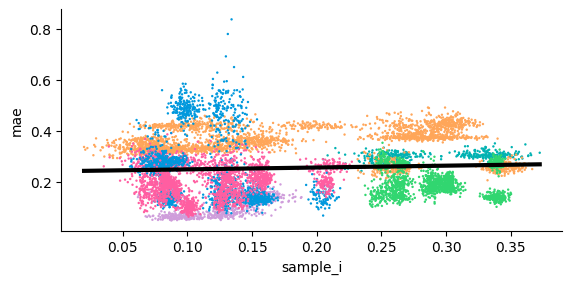

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (4,2))
g = sns.lmplot(
    data=df,
    x="sample_i",
    y="mae",
    col_wrap=None,
    ci=None,
    scatter=False,
    line_kws={"linewidth": 3, "color": 'k'},
    legend = False,
    height = 3, aspect=2
)



sns.scatterplot(in_data_chars, x='sample_i', y='mae', hue = 'category', s=3, palette=cpal, legend=False, edgecolor = 'none', rasterized=True)
plt.show()

### rank ~ MAE + Moran's I

In [25]:
df_long = joblib.load(projdir + '/results/stats/neuromaps_collected_ols_in_sill-normalized.pkl')

In [26]:
import statsmodels.formula.api as smf
df = df_long
df['mae'] = df['mae-sillnorm']
df["approach"] = df["approach"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ (mae + sample_i) *( C(approach) + C(percentage) + C(maptag) )",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     1363.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        15:51:50   Log-Likelihood:                 20475.
No. Observations:               57303   AIC:                        -4.076e+04
Df Residuals:                   57207   BIC:                        -3.990e+04
Df Model:                          95                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [27]:
np.where( model.pvalues == model.pvalues['mae'] )

(array([32]),)

In [28]:
from statsmodels.stats.multitest import multipletests

multipletests(model.pvalues, method = 'bonferroni')[1][32]

np.float64(1.0)

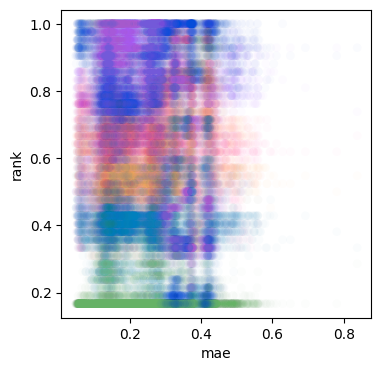

In [33]:
plt.figure(figsize = (4,4))
df_shorter = df.drop(columns = ['sample_i'])
df_shorter = df_shorter.drop_duplicates(subset=['mae', 'approach'])
sns.scatterplot(df_shorter, x= 'mae', y='rank', edgecolor = 'none', alpha = .02, s = 40, hue = 'approach', palette = apal, legend = False, rasterized=True)
plt.show()

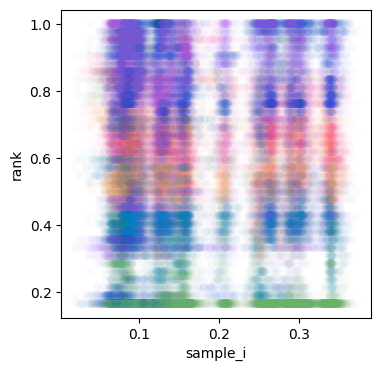

In [32]:
plt.figure(figsize = (4,4))
sns.scatterplot(df_long, x= 'sample_i', y='rank', edgecolor = 'none', alpha = .02, s = 40, \
                hue = 'approach', palette = apal, legend = False, rasterized=True)
plt.show()

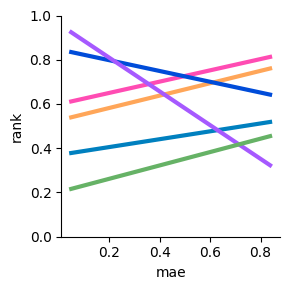

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df_long,
    x='mae',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": .01, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])

plt.tight_layout()

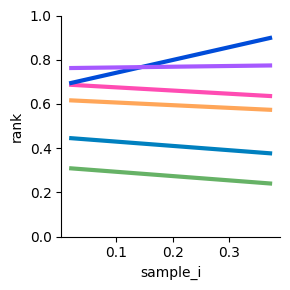

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df_long,
    x='sample_i',
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": .01, "edgecolor": "none", "rasterized": True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])

plt.tight_layout()

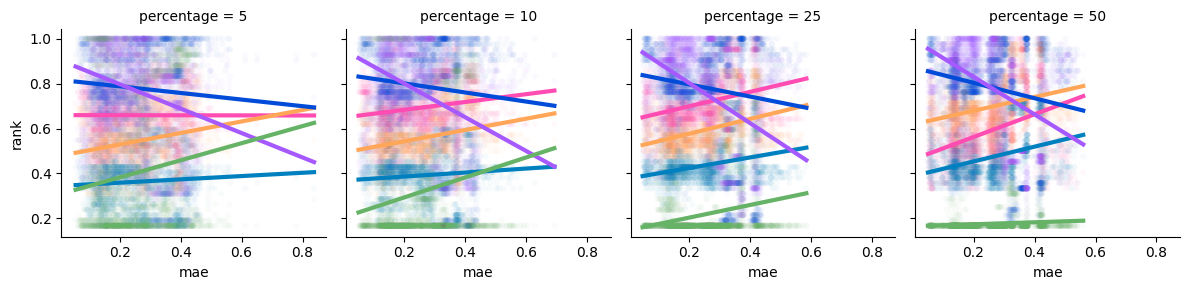

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='mae',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 20, "alpha": .03, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()

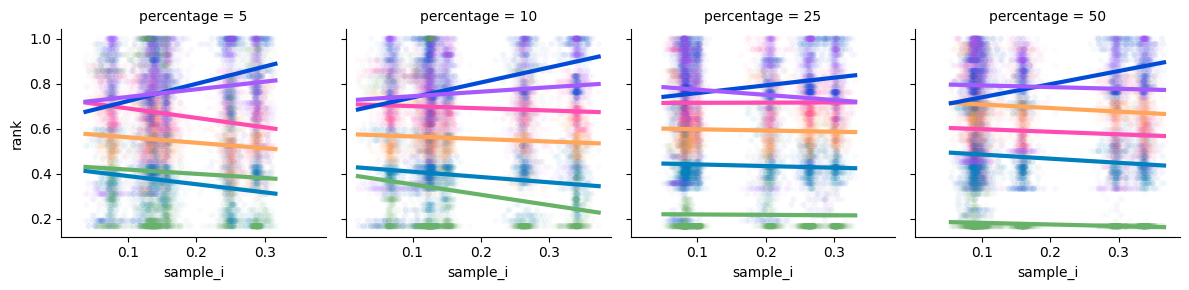

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))
g = sns.lmplot(
    data=df,
    x='sample_i',
    y="rank",
    hue="approach",
    col = "percentage",
    col_wrap=None,
    ci=None,
    scatter_kws={"s": 20, "alpha": .03, "edgecolor": "none", "rasterized":True},
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

plt.tight_layout()

## Which kriging

In [47]:
df_filtered = df_long[df_long["approach"].isin(["krige", "regkrige"])]
df_filtered["approach"] = df_filtered["approach"].astype("category").cat.remove_unused_categories()

/tmp/ipykernel_75388/2817635913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["approach"] = df_filtered["approach"].astype("category").cat.remove_unused_categories()


In [48]:
import statsmodels.formula.api as smf
df = df_filtered

df["approach"] = df["approach"].astype("category")
df["percentage"] = df["percentage"].astype("category")
df["maptag"] = df["maptag"].astype("category")

model = smf.ols(
    "rank ~ ( mae + sample_i ) * (C(approach) + C(percentage) + C(maptag))",
    data=df
).fit(cov_type="HC3")

print(model.summary())

/tmp/ipykernel_75388/2911087955.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["approach"] = df["approach"].astype("category")
/tmp/ipykernel_75388/2911087955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["percentage"] = df["percentage"].astype("category")
/tmp/ipykernel_75388/2911087955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     538.7
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        16:00:05   Log-Likelihood:                 10678.
No. Observations:               18936   AIC:                        -2.119e+04
Df Residuals:                   18852   BIC:                        -2.053e+04
Df Model:                          83                                         
Covariance Type:                  HC3                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

In [49]:
np.where( model.pvalues.index == 'mae:C(approach)[T.regkrige]' )

(array([29]),)

In [50]:
from statsmodels.stats.multitest import multipletests

multipletests(model.pvalues, method = 'bonferroni')

(array([ True,  True, False,  True,  True, False, False, False,  True,
         True, False,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False,  True,  True,  True,  True, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False,  True, False, False, False, False, False,
        False, False,  True, False,  True, False, False, False,  True,
        False, False, False, False, False,  True,  True, False,  True,
        False, False, False]),
 array([1.71350091e-005, 3.25794315e-188, 1.00000000e+000, 6.77045587e-010,
        1.35026204e-032, 1.01857593e-001, 2.36634672e-001, 1.00000000e+000,
        1.26025889e-005, 9.37771773e-003, 1.00000000e+000, 7.48063678e-004,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 4

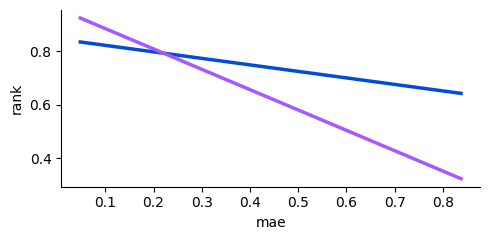

In [51]:
import seaborn as sns

g=sns.lmplot(
    data=df,
    x="mae",
    y="rank",
    hue="approach",        # krige vs regkrige
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": 0.02, "edgecolor": "none", "rasterized":True},
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.5},
    aspect = 2, height = 2.5
)

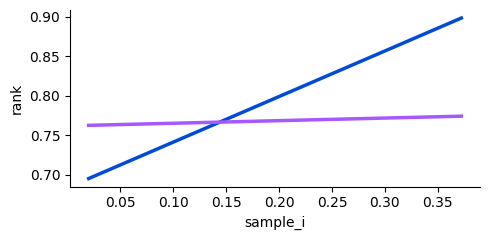

In [52]:
import seaborn as sns

g=sns.lmplot(
    data=df,
    x="sample_i",
    y="rank",
    hue="approach",        # krige vs regkrige
    ci=None,
    scatter=False,
    #scatter_kws={"s": 20, "alpha": 0.02, "edgecolor": "none", "rasterized":True},
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.5},
    aspect = 2, height = 2.5
)
